# Figure 7: Results from variant benchmarking algorithms

## Import packages

In [1]:
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Bio.Phylo as bp
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

## Load in results dataframe

In [11]:
# Define data paths
build = 'flu-simulated-150k-samples-final'
diagnostics_path = f"../results/{build}/variant_assignment_scores.tsv"
external_metrics_path = f"../results/{build}/variant_assignment_external_scores.tsv"
fig_path = "../../antigen-tex/figures"

In [12]:
diagnostics_df = pd.read_csv(diagnostics_path, sep="\t")
diagnostics_df.head()

,t,assignment_method,bic,r2,adj_r2,n_clusters
0,5,antigenic,-4350.279567,0.937679,0.937364,6
1,5,mds,-3447.790743,0.866588,0.866027,5
2,5,pca,-3372.507830,0.858752,0.858039,6
3,5,tsne,-2730.451644,0.756838,0.755815,5
4,5,umap,-3410.312496,0.864764,0.863852,8


In [4]:
external_metrics_df = pd.read_csv(external_metrics_path, sep="\t")
external_metrics_df.head()

,assignment_method,metric,score
0,variant_mds,NMI,0.821269
1,variant_mds,ARI,0.646862
2,variant_pca,NMI,0.835030
3,variant_pca,ARI,0.663645
4,variant_tsne,NMI,0.827556


In [6]:
methods_to_plot = ['antigenic', 'pca', 'mds', 'tsne', 'umap']
method_labels = {
    'antigenic': 'antigen-prime',
    'pca': 'pca',
    'mds': 'mds',
    'tsne': 't-sne',
    'umap': 'umap'
}

## Plot $R^2$ across methods

/var/folders/90/6t9_1yk52qd_sbpbmt4ym0540000gn/T/ipykernel_30989/895996608.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([method_labels[method] for method in methods_to_plot], fontsize=14)


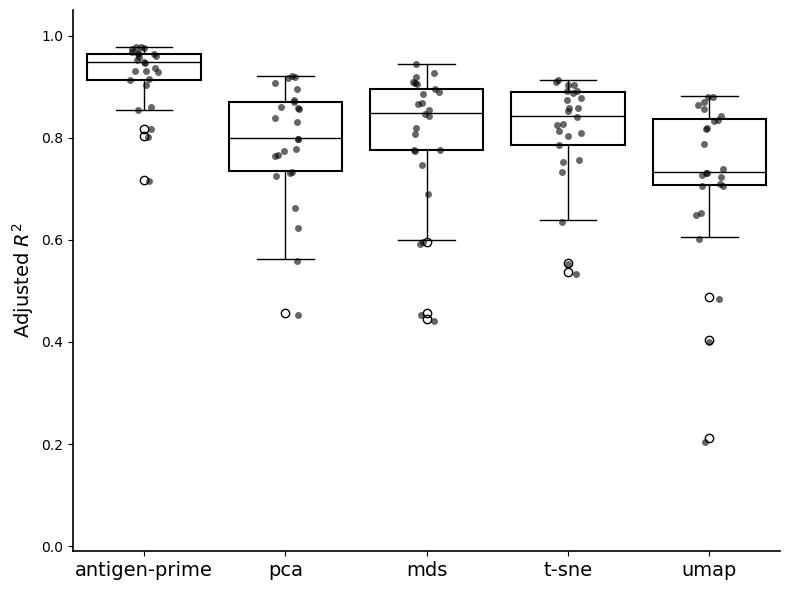

In [16]:
# Create the boxplot with hue for colors
fig, ax = plt.subplots(figsize=(8, 6))
# Grab methods to plot in order
plot_df = diagnostics_df[diagnostics_df['assignment_method'].isin(methods_to_plot)]
# Set categorical order for x-axis
plot_df['assignment_method'] = pd.Categorical(
    plot_df['assignment_method'], 
    categories=['antigenic', 'pca', 'mds', 'tsne', 'umap'],
    ordered=True
)

sns.boxplot(
    data=plot_df,
    x='assignment_method',
    y='r2',
    color='black',
    showfliers=True,
    ax=ax,
    legend=False  # Explicitly disable legend
)

# Apply outlined box styling
for patch in ax.patches:
    edge_color = patch.get_facecolor()
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(1.5)

# Overlay stripplot with individual points
sns.stripplot(
    data=plot_df,
    x='assignment_method',
    y='adj_r2',
    color='black',
    dodge=True, 
    jitter=True, 
    size=5, 
    alpha=0.6,
    edgecolor='white',
    legend=False,  # Avoid duplicate legends
    ax=ax
)

# Remove any legends that might have been created
if ax.get_legend():
        ax.get_legend().remove()

# Customize x-tick labels
ax.set_xticklabels([method_labels[method] for method in methods_to_plot], fontsize=14)
ax.set_xlabel('')
ax.set_ylabel(r'Adjusted $R^2$', fontsize=14)
ax.set_ylim(-0.01, 1.05)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig(f'{fig_path}/variant_assignment_adj_r2.pdf')
plt.show()

## Plot $R^2$ across methods, but split by selection regime

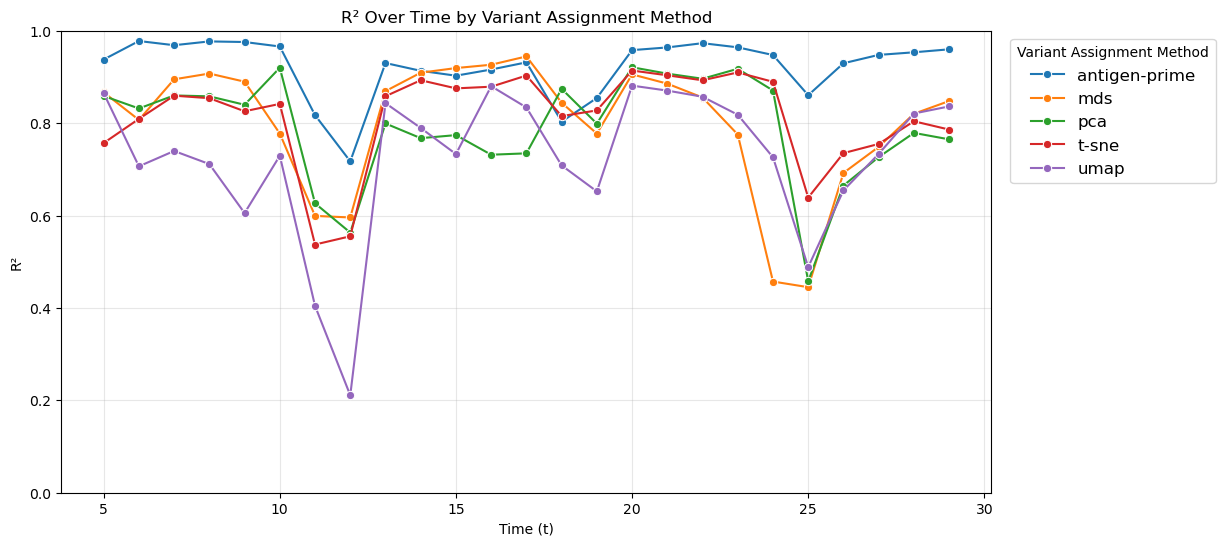

In [8]:
# R² over time for both methods
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='t', y='r2', hue='assignment_method', marker='o')

#Get current handles and labels from the plot
handles, labels = plt.gca().get_legend_handles_labels()

# Create new labels by mapping the old ones
new_labels = [method_labels.get(label, label) for label in labels]

# Replace the legend with properly mapped labels
plt.legend(handles, new_labels, title='Variant Assignment Method', fontsize=12, 
           title_fontsize=10, loc='upper right', bbox_to_anchor=(1.25, 1))
# Add labels and title
plt.title('R² Over Time by Variant Assignment Method')
plt.xlabel('Time (t)')
plt.ylabel('R²')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

## Plot number of clusters across methods

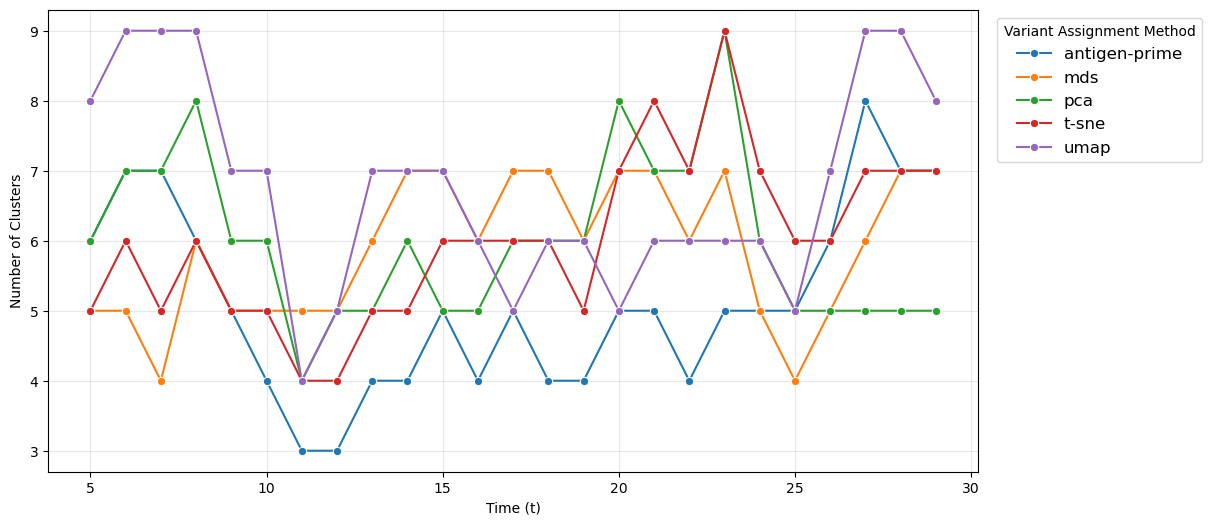

In [9]:
# R² over time for both methods
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='t', y='n_clusters', hue='assignment_method', marker='o')

#Get current handles and labels from the plot
handles, labels = plt.gca().get_legend_handles_labels()

# Create new labels by mapping the old ones
new_labels = [method_labels.get(label, label) for label in labels]

# Replace the legend with properly mapped labels
plt.legend(handles, new_labels, title='Variant Assignment Method', fontsize=12, 
           title_fontsize=10, loc='upper right', bbox_to_anchor=(1.25, 1))
# Add labels
plt.xlabel('Time (t)')
plt.ylabel('Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

## Create and dump table of external metrics

In [10]:
# Pivot the external metrics dataframe for a better table format
pivot_df = external_metrics_df.pivot(index='assignment_method', columns='metric', values='score')

# Clean up method names to match the format in the image
method_name_map = {
    'variant_mds': 'mds',
    'variant_pca': 'pca',
    'variant_tsne': 't-sne',
    'variant_umap': 'umap'
}
pivot_df.index = pivot_df.index.map(lambda x: method_name_map.get(x, x))

# Reorder columns to match the example (ARI, FMI, NMI)
pivot_df = pivot_df[['ARI', 'NMI']]

# Now expand column names into full names
column_name_map = {
    'ARI': r'\textbf{Adjusted Rand Index}',
    'NMI': r'\textbf{Normalized Mutual Information}'
}
pivot_df.rename(columns=column_name_map, inplace=True)

# Create LaTeX table with bold maximum values
def make_latex_table_with_bold_max(df):
    lines = []
    lines.append(r'\begin{table}[h]')
    lines.append(r'\centering')
    lines.append(r'\begin{tabular}{|l|' + 'c|' * len(df.columns) + '}')
    lines.append(r'\hline')
    
    # Header
    header = r'\textbf{Method} & ' + ' & '.join(df.columns) + r' \\'
    lines.append(header)
    lines.append(r'\hline')
    
    # Find max value for each column
    max_vals = df.max()
    
    # Data rows
    for idx in df.index:
        row_vals = []
        for col in df.columns:
            val = df.loc[idx, col]
            # Format to 3 decimal places
            val_str = f'{val:.3f}'
            # Bold if it's the max value
            if val == max_vals[col]:
                val_str = r'\textbf{' + val_str + '}'
            row_vals.append(val_str)
        
        row_line = f'{idx} & ' + ' & '.join(row_vals) + r' \\'
        lines.append(row_line)
    
    lines.append(r'\hline')
    lines.append(r'\end{tabular}')
    lines.append(r'\caption{External validation metrics for variant assignment methods.}')
    lines.append(r'\label{tab:variant_assignment_external_metrics}')
    lines.append(r'\end{table}')
    
    return '\n'.join(lines)

# Generate the LaTeX table
latex_table = make_latex_table_with_bold_max(pivot_df)

# Save to file - ensure directory exists
import os
output_path = '../../antigen-tex/tables/variant_assignment_external_metrics.tex'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'w') as f:
    f.write(latex_table)

print(f"LaTeX table saved to: {output_path}")
print("\nPreview:")
print(latex_table)

LaTeX table saved to: ../../antigen-tex/tables/variant_assignment_external_metrics.tex

Preview:
\begin{table}[h]
\centering
\begin{tabular}{|l|c|c|}
\hline
\textbf{Method} & \textbf{Adjusted Rand Index} & \textbf{Normalized Mutual Information} \\
\hline
mds & 0.647 & 0.821 \\
pca & \textbf{0.664} & \textbf{0.835} \\
t-sne & 0.661 & 0.828 \\
umap & 0.556 & 0.753 \\
\hline
\end{tabular}
\caption{External validation metrics for variant assignment methods.}
\label{tab:variant_assignment_external_metrics}
\end{table}
